# Mathematical programming

Mathematical programming is an area of computer science concerned with finding the optimal solution to a particular problem among all possible solutions that satisfy specified conditions. In brief: we describe the problem using mathematical expressions (a mathematical model) and then use ready-made algorithms (implemented as solvers) to find optimal parameter values.

It is worth emphasising that *mathematical programming* does not directly mean writing source code. The term originally refers to planning and the optimal allocation of resources — in other words, a plan of action, or a *programme*. Importantly, in the early days of computing (for example, when the simplex algorithm was introduced in 1947), the word *programming* was not yet automatically associated with writing code. This is why the modern term *mathematical programming* can be ambiguous.

The main classes of mathematical-programming problems are:

1. Linear programming (LP)
   1. All relationships — both the objective function and the constraints — are linear functions, while the parameters may take arbitrary real values.
   2. Example: optimising the composition of a fuel mixture or a production plan that minimises costs subject to specified resource limits.
2. Integer programming (IP)
   1. A family of methods closely related to linear programming. Model variables must take integer or binary values.
   2. Example: a model supporting a medical decision.
3. Mixed-integer linear programming (MILP)
   1. A combination of LP and IP in which some model variables are integer-valued and others are real-valued.
   2. Example: scheduling refinery operations or planning delivery routes while accounting for drivers' working time and the number of lorries.
4. Nonlinear programming (NLP)
   1. At least one function (in the objective or the constraints) is nonlinear, for example because it contains polynomial relationships, trigonometric functions, etc. This is a very common mathematical-programming paradigm because nonlinear relationships are abundant in real-world problems.
   2. Example: optimising chemical processes in which reactions typically depend nonlinearly on temperature and pressure.

In optimisation, mathematical programming is complemented by heuristic and numerical methods, each intended for particular classes of optimisation problems. Mathematical programming requires an explicit mathematical structure represented as a model. Algorithms used in mathematical programming treat the model as a white box: they exploit analytical properties of the formula to determine an optimal solution.

Mathematical models optimised in this way should have the following properties:
- explicit objective and constraint functions, allowing optimisation algorithms to exploit analytical methods such as differential calculus;
- linearity or convexity where applicable: linear functions define a polyhedral feasible region whose extrema lie at vertices, while convex functions guarantee that local minima are also global minima;
- discreteness and discontinuity for integer or binary variables, where the objective becomes a discrete (combinatorial) function. Mathematical-programming methods handle such cases by systematically partitioning and pruning the solution space.

When should mathematical programming be used? Whenever a problem can be formulated as a mathematical model, particularly a linear one. Under such conditions, modern optimisation methods can provide a **guarantee of optimality**.

There are also cases in which mathematical programming does not provide such a guarantee. When the objective-function formula is unknown, extremely irregular, strongly nonlinear, or discontinuous, heuristic methods are usually more appropriate. If the problem can be expressed as a model with a continuous search space and a smooth function involving a very large number of parameters, gradient-based methods may be a good solution. We will return to these approaches in later lectures.

## Mathematical programming in the modern toolset

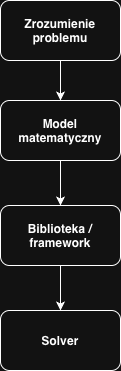

| Library / framework | LP | NLP | Entry barrier | Ease of integration with solvers |
| :--- | :---: | :---: | :---: | :---: |
| [Pyomo](https://pypi.org/project/pyomo/) | X | X | Low | High |
| [OR-Tools](https://pypi.org/project/ortools/) | X | | Very low | Low |
| [PuLP](https://pypi.org/project/PuLP/) | X | | Low | High |
| [SCIP](https://pypi.org/project/PySCIPOpt/) | X | X | Very low | Low |
| [SciPy](https://pypi.org/project/scipy/) | X | X | Moderate | Moderate |

| Solver | LP | NLP | Licence |
| :--- | :---: | :---: | :---: |
| [Gurobi](https://www.gurobi.com) | X | | commercial |
| [CPLEX](https://www.ibm.com/products/ilog-cplex-optimization-studio/cplex-optimizer) | X | | commercial |
| [CBC](https://github.com/coin-or/cbc) | X | | open source |
| [GLPK](https://www.gnu.org/software/glpk/glpk.html) | X | | open source |
| [IPOPT](https://github.com/coin-or/ipopt) | | X | open source |
| [SCIP](https://github.com/scipopt/scip) | X | X | open source |
| [BARON](https://minlp.com/baron-solver) | | X | commercial |

### Linear programming

#### Problem 1: optimisation of a simple linear function

objective function: $max (x+y)$

constraints:
- $-x + 2y \leq 8$
- $2x + y \leq 14$
- $2x - y \leq 10$
- $0 \leq x \leq 10$
- $0 \leq y \leq 10$

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
def draw_model(
        constraints: list,
        target_fn: callable,
        optimal_parameters: tuple | None = None,
        ) -> None:
    # define the variable space (domain)
    x_vals = np.linspace(0, 10, 500)
    y_vals = np.linspace(0, 10, 500)
    X, Y = np.meshgrid(x_vals, y_vals)

    Z = target_fn(X, Y)

    # feasible region: intersection of all constraints
    feasible_region = np.logical_and.reduce([c(X, Y) for c in constraints])

    # visualisation
    plt.figure(figsize=(9, 7))
    contour = plt.contour(X, Y, Z, levels=20, cmap="viridis", alpha=0.6)
    plt.clabel(contour, inline=True, fontsize=9, fmt="z=%.1f")

    if optimal_parameters:
        plt.plot(*optimal_parameters, "ro", markersize=8, label=f"Global optimum {optimal_parameters}")
    
    plt.imshow(
        feasible_region,
        extent=(0, 10, 0, 10),
        origin="lower",
        cmap="Greens",
        alpha=0.4,
        aspect="auto",
    )

    colors = ["red", "blue", "green", "purple", "orange"]
    for c, color in zip(constraints, colors):
        plt.contour(
            X, Y, c(X, Y), levels=[0], colors=color, linestyles="dashed"
        )

    plt.xlim(0, 10)
    plt.ylim(0, 10)
    plt.xlabel("x")
    plt.ylabel("y")
    plt.title(
        "Visualisation of the mathematical model",
        fontsize=12,
    )
    plt.grid(True, linestyle=":", alpha=0.6)
    plt.colorbar(contour, label="Objective-function value (Z)")

    plt.show()

In [ ]:
constraints = [
    lambda x, y: -x + 2 * y <= 8,
    lambda x, y: 2 * x + y <= 14,
    lambda x, y: 2 * x - y <= 10,
    lambda x, y: (x >= 0) & (x <= 10),
    lambda x, y: (y >= 0) & (y <= 10),
]
target = lambda x, y: x + y

draw_model(
    constraints=constraints,
    target_fn=target,
)

In [ ]:
import pyomo.environ as pyo
from pyomo.opt import SolverFactory

The first step is to create an object representing the mathematical model.

In [ ]:
model = pyo.ConcreteModel()

Next, define the variables that will be optimised — that is, the values to be searched so as to maximise the objective function. Here we set the search range from 0 to 10, in accordance with the constraints.

In [ ]:
model.x = pyo.Var(bounds=(0, 10))
model.y = pyo.Var(bounds=(0, 10))

Then define the constraints.

In [ ]:
x = model.x
y = model.y

In [ ]:
model.c1 = pyo.Constraint(expr= -x+2*y<=8)
model.c2 = pyo.Constraint(expr= 2*x+y<=14)
model.c3 = pyo.Constraint(expr= 2*x-y<=10)

Next, define the objective function together with the direction of optimisation. Here we maximise the objective, i.e. search for the **maximum** value of the function.

In [ ]:
model.obj = pyo.Objective(expr= x+y, sense=pyo.maximize)

It is good practice to inspect the contents of the model periodically. This becomes particularly useful for more complex problems.

In [ ]:
model.pprint()

Search for a solution, i.e. run the solver.

In [ ]:
opt = SolverFactory("glpk")

In [ ]:
opt.solve(model)

Retrieve the results.

In [ ]:
x_val = pyo.value(x)
y_val = pyo.value(y)

In [ ]:
x_val, y_val

#### Problem 2: array-indexed parameters

The objective is to find a configuration of electricity production across five generators that supplies three demand points at the lowest possible cost. To make the problem slightly more interesting, assume that demand point 0 is connected only to generators 0 and 3.

| ID | Cost of 1 kW | Maximum output |
|----|------|----------------------|
| 0  | 0.10 | 20 kW                |
| 1  | 0.05 | 10 kW                |
| 2  | 0.30 | 40 kW                |
| 3  | 0.40 | 40 kW                |
| 4  | 0.01 | 5 kW                 |

| ID | Demand |
|----|-------------|
| 0  | 50 kW       |
| 1  | 20 kW       |
| 2  | 30 kW       |

Assumptions:
- $C$ — cost [variable]
- $P$ [parameter] — current electricity production (kW)

Objective:
- $min \sum_{i_g = 0}^4 C_g(i_g)P_g(i_g)$

Constraints:
- $\sum_{i_g = 0}^4 P_g(i_g) = \sum_{i_d = 0}^2 P_d(i_d)$ — total electricity currently generated must equal total demand
- $P_d(0) \leq P_g(0) + P_g(3)$ — demand point 0 is connected only to generators 0 and 3
- $P_g(i_g) \geq 0 \forall i_g$ — electricity production must be non-negative for every generator
- $P_g(i_g) \leq P_g(i_g)^{lim} \forall i_g$ — electricity production cannot exceed the maximum capacity of any generator

In [ ]:
import pandas as pd

In [ ]:
energy_gen = pd.DataFrame.from_records([
    [0.10, 20],
    [0.05, 10],
    [0.30, 40],
    [0.40, 50],
    [0.01, 5 ],
], columns=["Cost", "Maximum power generation"])

In [ ]:
energy_demand = pd.DataFrame.from_records([
    [50],
    [20],
    [30],
], columns=["Load demand"])

In [ ]:
generator_amount = len(energy_gen)

In [ ]:
model = pyo.ConcreteModel()

The parameter `pg` receives as many values as there are available generators.

In [ ]:
model.pg = pyo.Var(range(generator_amount), bounds=(0, None))
pg = model.pg

Constraints

In [ ]:
pg_sum = sum([pg[g] for g in range(generator_number)])
model.balance = pyo.Constraint(expr=(pg_sum == energy_demand["Load demand"].sum()))
model.cond = pyo.Constraint(expr=(pg[0] + pg[3] >= energy_demand["Load demand"][0]))

In [ ]:
model.limits = pyo.ConstraintList()

for g in range(generator_amount):
    model.limits.add(expr=(pg[g] <= energy_gen["Maximum power generation"][g]))

In [ ]:
model.minimums = pyo.ConstraintList()

for g in range(generator_amount):
    model.minimums.add(expr=(pg[g] >= 0))

Objective function

In [ ]:
model.obj = pyo.Objective(expr=(
    sum(pg[g] * energy_gen["Cost"][g] for g in range(generator_amount))
))

And... the solution

In [ ]:
opt = SolverFactory("glpk")

In [ ]:
results = opt.solve(model)

In [ ]:
energy_gen["Expected generation"] = [pyo.value(pg[g]) for g in range(generator_number)]

In [ ]:
energy_gen

#### Problem 3: graph optimisation

Problem 3, "routing", from Lecture 0.

In [ ]:
model = pyo.ConcreteModel()

In [ ]:
model.all_points = ["A", "v1", "v2", "v3", "B"]
model.intermediate_points = ["v1", "v2", "v3"]

In [ ]:
model.all_routes = [
    ["A", "v1"],
    ["A", "v2"],
    ["v1", "v2"],
    ["v2", "v1"],
    ["v1", "B"],
    ["v2", "v3"],
    ["v3", "B"],
]

In [ ]:
model.routes_from = {key: [] for key in model.all_points}
model.routes_to = {key: [] for key in model.all_points}

In [ ]:
for route in model.all_routes:
    model.routes_from[route[0]].append(route[1])
    model.routes_to[route[1]].append(route[0])

In [ ]:
model.distances = {}
model.distances["A", "v1"] = 2
model.distances["A", "v2"] = 7
model.distances["v1", "v2"] = 10
model.distances["v2", "v1"] = 10
model.distances["v1", "B"] = 30
model.distances["v2", "v3"] = 8
model.distances["v3", "B"] = 5

The model variables represent connections between nodes (present / absent).

In [ ]:
model.x = pyo.Var(model.all_routes, within=pyo.Binary)

Objective function:

In [ ]:
model.obj = pyo.Objective(expr= sum(
    [model.x[route[0], route[1]] * model.distances[route[0], route[1]] for route in model.all_routes]
), sense=pyo.minimize)

Model constraints

In [ ]:
model.c1 = pyo.Constraint(expr = sum([model.x["A", j] for j in model.routes_from["A"]]) == 1)
model.c2 = pyo.Constraint(expr = sum([model.x[i,"B"] for i in model.routes_to["B"]]) == 1)
model.c3 = pyo.ConstraintList()
for i in model.intermediate_points:
    model.c3.add(sum([model.x[i,j] for j in model.routes_from[i]]) == sum([model.x[j,i] for j in model.routes_to[i]]))

Solution

In [ ]:
opt = SolverFactory("glpk")
model.results = opt.solve(model)

The final solution consists of the edges whose Boolean values are true.

In [ ]:
for route in model.all_routes:
    if pyo.value(model.x[route[0], route[1]]) == 1:
        print('Route activated: %s-%s' % (route[0], route[1]))

### (Mixed-)integer programming

As we know, integer programming introduces the additional assumption that selected variables (in the mixed case) or all variables take integer values. In `Pyomo`, this is specified using the argument `within=pyo.Integers` passed to the `Var` class constructor.

We will reuse Problem 1 from the linear-programming section, adding the assumption that parameter `x` must be an integer.

In [ ]:
model = pyo.ConcreteModel()

In [ ]:
model.x = pyo.Var(within=pyo.Integers, bounds=(0, 10))
model.y = pyo.Var(bounds=(0, 10))

In [ ]:
x = model.x
y = model.y

In [ ]:
model.c1 = pyo.Constraint(expr= -x+2*y<=7)
model.c2 = pyo.Constraint(expr= 2*x+y<=14)
model.c3 = pyo.Constraint(expr= 2*x-y<=10)

In [ ]:
model.obj = pyo.Objective(expr= x+y, sense=pyo.maximize)

In [ ]:
opt = SolverFactory("glpk")

In [ ]:
opt.solve(model)

In [ ]:
x_val = pyo.value(x)
y_val = pyo.value(y)

In [ ]:
x_val, y_val

## Nonlinear programming

For nonlinear programming, special attention must be paid to the choice of solver. The `glpk` solver used above supports only linear models. For nonlinear problems, we will use the `ipopt` solver.

We will solve the following nonlinear model.

objective function: $max (x+xy)$

constraints:
- $-x + 2yx \leq 8$
- $2x + y \leq 14$
- $2x - y \leq 10$
- $0 \leq x \leq 10$
- $0 \leq y \leq 10$

In [ ]:
constraints = [
    lambda x, y: -x + 2 * x * y <= 8,
    lambda x, y: 2 * x + y <= 14,
    lambda x, y: 2 * x - y <= 10,
    lambda x, y: (x >= 0) & (x <= 10),
    lambda x, y: (y >= 0) & (y <= 10),
]
target = lambda x, y: x + x * y

draw_model(
    constraints=constraints,
    target_fn=target,
)

In [ ]:
model = pyo.ConcreteModel()

In [ ]:
model.x = pyo.Var(bounds=(0, 10))
model.y = pyo.Var(bounds=(0, 10))

In [ ]:
x = model.x
y = model.y

In [ ]:
model.c1 = pyo.Constraint(expr= -x+2*y*x<=8)
model.c2 = pyo.Constraint(expr= 2*x+y<=14)
model.c3 = pyo.Constraint(expr= 2*x-y<=10)

In [ ]:
model.obj = pyo.Objective(expr= x+x*y, sense=pyo.maximize)

Note that the path to the solver executable can be passed directly using the `executable` argument in the `SolverFactory` constructor.

In [ ]:
opt = SolverFactory("ipopt", executable="/opt/homebrew/bin/ipopt")

In [ ]:
opt.solve(model)

In [ ]:
x_val = pyo.value(x)
y_val = pyo.value(y)

In [ ]:
x_val, y_val

In [ ]:
draw_model(
    constraints=constraints,
    target_fn=target,
    optimal_parameters=(x_val, y_val),
)

## Mixed-integer nonlinear programming

The idea of mixed-integer nonlinear programming (MINLP) should now be clear. We have a nonlinear mathematical model in which the objective function and/or the constraints are nonlinear. In addition, selected variables are restricted to integer values. From the point of view of solver selection, this considerably narrows the available options. `Pyomo`, however, provides useful functionality that allows two solvers designed for the component problem classes — NLP and MILP — to be combined. This can be done using the `mip_solver` and `nlp_solver` arguments of the `solve` method.

We will reuse the optimisation problem from the previous example.

objective function: $max (x+xy)$

constraints:
- $-x + 2yx \leq 8$
- $2x + y \leq 14$
- $2x - y \leq 10$
- $0 \leq x \leq 10$
- $0 \leq y \leq 10$

Additionally, variable `x` must be an integer.

In [ ]:
model = pyo.ConcreteModel()

In [ ]:
model.x = pyo.Var(within=pyo.Integers, bounds=(0, 10))
model.y = pyo.Var(bounds=(0, 10))

In [ ]:
x = model.x
y = model.y

In [ ]:
model.c1 = pyo.Constraint(expr= -x+2*y*x<=8)
model.c2 = pyo.Constraint(expr= 2*x+y<=14)
model.c3 = pyo.Constraint(expr= 2*x-y<=10)

In [ ]:
model.obj = pyo.Objective(expr= x+x*y, sense=pyo.maximize)

Combining optimisers for MINLP requires the `mindtpy` alias for the selected solver.

In [ ]:
opt = SolverFactory("mindtpy")

In [ ]:
opt.solve(model, mip_solver="glpk", nlp_solver="ipopt")

In [ ]:
x_val = pyo.value(x)
y_val = pyo.value(y)

In [ ]:
x_val, y_val

In [ ]:
draw_model(
    constraints=constraints,
    target_fn=target,
    optimal_parameters=(x_val, y_val),
)